In [17]:
# import torch
# import torch.nn as nn
# import torch.nn.functional as F
# import imageio

# img = imageio.imread('/localhome/asa420/MIAL/data/confocal-data/vess_enh_unet/climp/images/climp1_er_mean.png')

# t = torch.tensor(img)

# t = torch.unsqueeze(t, 0)
# t = torch.unsqueeze(t, 0)
# t = t.to(torch.float32)
# # t.shape

# op = F.max_pool2d(t, (3,3), (1,1), (1,1))

# # p1 = -F.max_pool2d(-t, (3,1), (1,1), (1,0))

# op

In [3]:
import torch
import torch.nn as nn

class NerdyNet(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(NerdyNet, self).__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        self.mid_level = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 192, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
        )

        self.decoder = nn.Sequential(
            nn.Conv2d(192, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(64, out_channels, kernel_size=2, stride=2, output_padding=0),
        )

    def forward(self, x):
        x1 = self.encoder(x)
        x2 = self.mid_level(x1)
        x3 = self.decoder(x2)
        return x3




In [4]:
import os
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms


class ERDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.classes = os.listdir(root_dir)

    def __len__(self):
        return sum(len(os.listdir(os.path.join(self.root_dir, cls, 'images'))) for cls in self.classes)

    def __getitem__(self, idx):
        current_class_idx = 0
        while idx >= len(os.listdir(os.path.join(self.root_dir, self.classes[current_class_idx], 'images'))):
            idx -= len(os.listdir(os.path.join(self.root_dir, self.classes[current_class_idx], 'images')))
            current_class_idx += 1

        current_class = self.classes[current_class_idx]
        img_folder = os.path.join(self.root_dir, current_class, 'images')
        mask_folder = os.path.join(self.root_dir, current_class, 'masks')

        img_name = os.listdir(img_folder)[idx]
        img_path = os.path.join(img_folder, img_name)
        mask_name = os.path.splitext(img_name)[0] + '_mask.png'  # Assuming mask files have the same name as images with '_mask' appended
        mask_path = os.path.join(mask_folder, mask_name)

        image = Image.open(img_path)#.convert("RGB")
        mask = Image.open(mask_path)#.convert("L")  # Convert to grayscale mask

        if self.transform:
            image = self.transform(image)
            mask = self.transform(mask)

        return image, mask

In [5]:
# from nerdynet.cldice import soft_cldice, soft_dice_cldice

In [19]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

def soft_erode(img):
    if len(img.shape)==4:
        p1 = -F.max_pool2d(-img, (3,1), (1,1), (1,0))
        p2 = -F.max_pool2d(-img, (1,3), (1,1), (0,1))
        return torch.min(p1,p2)
    elif len(img.shape)==5:
        p1 = -F.max_pool3d(-img,(3,1,1),(1,1,1),(1,0,0))
        p2 = -F.max_pool3d(-img,(1,3,1),(1,1,1),(0,1,0))
        p3 = -F.max_pool3d(-img,(1,1,3),(1,1,1),(0,0,1))
        return torch.min(torch.min(p1, p2), p3)


def soft_dilate(img):
    if len(img.shape)==4:
        return F.max_pool2d(img, (3,3), (1,1), (1,1))
    elif len(img.shape)==5:
        return F.max_pool3d(img,(3,3,3),(1,1,1),(1,1,1))


def soft_open(img):
    return soft_dilate(soft_erode(img))


def soft_skel(img, iter_):
    img1 = soft_open(img)
#     print(img1[0])
    skel = F.relu(img-img1)
#     print(torch.unique(skel[0]))
    for j in range(iter_):
        img  =  soft_erode(img)
        img1  =  soft_open(img)
        delta  =  F.relu(img-img1)
#         print(f'delta_{j}:{torch.unique(delta[0])}')
        skel  =  skel +  F.relu(delta-skel*delta)
#         print(f'skel_{j}: {torch.unique(skel[0])}')
    return skel


class soft_cldice(nn.Module):
    def __init__(self, iter_=1, smooth = 1.):
        super(soft_cldice, self).__init__()
        self.iter = iter_
        self.smooth = smooth

    def forward(self, y_true, y_pred):
        print(type(y_pred))
        skel_pred = soft_skel(y_pred, self.iter)
#         print(skel_pred.shape)
#         plt.imshow(skel_pred[0][0].cpu())
        skel_true = soft_skel(y_true, self.iter)
#         print(torch.multiply(skel_pred, y_true)[0])
#         print(torch.multiply(skel_pred, y_true).shape)
        print(f'skel_pred: {torch.unique(skel_pred)}')
        print(f'skel_true: {torch.unique(skel_true)}')
        
        tprec = (torch.sum(torch.multiply(skel_pred, y_true)[:,1:,...])+self.smooth)/(torch.sum(skel_pred[:,1:,...])+self.smooth)    
        tsens = (torch.sum(torch.multiply(skel_true, y_pred)[:,1:,...])+self.smooth)/(torch.sum(skel_true[:,1:,...])+self.smooth)    
#         print(f'tprec: {tprec}')
#         print(f'tsens: {tsens}')
        cl_dice = 1.- 2.0*(tprec*tsens)/(tprec+tsens)
        return cl_dice

# def soft_dice(y_true, y_pred):
#     """[function to compute dice loss]

#     Args:
#         y_true ([float32]): [ground truth image]
#         y_pred ([float32]): [predicted image]

#     Returns:
#         [float32]: [loss value]
#     """
#     smooth = 1
#     intersection = torch.sum((y_true * y_pred)[:,1:,...])
#     coeff = (2. *  intersection + smooth) / (torch.sum(y_true[:,1:,...]) + torch.sum(y_pred[:,1:,...]) + smooth)
#     return (1. - coeff)


# class soft_dice_cldice(nn.Module):
#     def __init__(self, iter_=3, alpha=0.5, smooth = 1.):
#         super(soft_cldice, self).__init__()
#         self.iter = iter_
#         self.smooth = smooth
#         self.alpha = alpha

#     def forward(y_true, y_pred):
#         dice = soft_dice(y_true, y_pred)
#         skel_pred = soft_skel(y_pred, self.iter)
#         skel_true = soft_skel(y_true, self.iter)
#         tprec = (torch.sum(torch.multiply(skel_pred, y_true)[:,1:,...])+self.smooth)/(torch.sum(skel_pred[:,1:,...])+self.smooth)    
#         tsens = (torch.sum(torch.multiply(skel_true, y_pred)[:,1:,...])+self.smooth)/(torch.sum(skel_true[:,1:,...])+self.smooth)    
#         cl_dice = 1.- 2.0*(tprec*tsens)/(tprec+tsens)
#         return (1.0-self.alpha)*dice+self.alpha*cl_dice

In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import transforms


import numpy as np

np.random.seed(34)
torch.manual_seed(34)



in_channels = 1
out_channels = 1  # Assuming binary segmentation
model = NerdyNet(in_channels, out_channels)

# Define your loss function and optimizer
# criterion = nn.BCEWithLogitsLoss()
criterion = soft_cldice()
optimizer = optim.Adam(model.parameters(), lr=0.001)

#TODO: Add data augmentation


# Define your transformation
transform = transforms.Compose([
#     transforms.Resize((128, 128)),
    transforms.ToTensor(),
    #transforms.GaussianBlur(3),
    #transforms.RandomHorizontalFlip(p=0.6)
])

# Define your dataset

root_dir = '/localhome/asa420/MIAL/data/confocal-data/vess_enh_unet/'

dataset = ERDataset(root_dir, transform=transform)


# Assuming an 80-20 train-test split
train_size = int(0.85 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

batch_size = 1
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Training loop
num_epochs = 1
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

for epoch in range(num_epochs):
    model.train()
    for inputs, masks in train_loader:
        inputs, masks = inputs.to(device), masks.to(device)

        # Forward pass
        outputs = model(inputs)
#         outputs = (torch.sigmoid(outputs) > 0.5).float()
        loss = criterion(outputs, masks)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # Print the training loss for each epoch
    print(f"Epoch [{epoch + 1}/{num_epochs}], Training Loss: {loss.item()}")

# Testing loop
model.eval()
test_loss = 0.0
with torch.no_grad():
    for inputs, masks in test_loader:
        inputs, masks = inputs.to(device), masks.to(device)

        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, masks)
        test_loss += loss.item()

# Calculate and print the average test loss
average_test_loss = test_loss / len(test_loader)
print(f"Average Test Loss: {average_test_loss}")

# Save the trained model
# torch.save(model.state_dict(), 'unet_model_oct17.pth')


<class 'torch.Tensor'>
skel_pred: tensor([0., 1.], device='cuda:0')
skel_true: tensor([0.0000e+00, 5.9605e-08, 7.4506e-08,  ..., 1.2505e-01, 1.2505e-01,
        1.2508e-01], device='cuda:0', grad_fn=<Unique2Backward0>)
<class 'torch.Tensor'>
skel_pred: tensor([0., 1.], device='cuda:0')
skel_true: tensor([0.0000e+00, 1.4901e-08, 2.9802e-08,  ..., 1.2607e-01, 1.2615e-01,
        1.2807e-01], device='cuda:0', grad_fn=<Unique2Backward0>)
<class 'torch.Tensor'>
skel_pred: tensor([0., 1.], device='cuda:0')
skel_true: tensor([0.0000e+00, 1.4901e-08, 4.4703e-08,  ..., 1.2537e-01, 1.2544e-01,
        1.2575e-01], device='cuda:0', grad_fn=<Unique2Backward0>)
<class 'torch.Tensor'>
skel_pred: tensor([0., 1.], device='cuda:0')
skel_true: tensor([0.0000e+00, 2.9802e-08, 5.9605e-08,  ..., 1.2502e-01, 1.2508e-01,
        1.2509e-01], device='cuda:0', grad_fn=<Unique2Backward0>)
<class 'torch.Tensor'>
skel_pred: tensor([0., 1.], device='cuda:0')
skel_true: tensor([0.0000e+00, 1.4901e-08, 2.9802e-08,  

<class 'torch.Tensor'>
skel_pred: tensor([0., 1.], device='cuda:0')
skel_true: tensor([0.0000e+00, 2.9802e-08, 4.4703e-08,  ..., 1.2578e-01, 1.2590e-01,
        1.2601e-01], device='cuda:0', grad_fn=<Unique2Backward0>)
<class 'torch.Tensor'>
skel_pred: tensor([0., 1.], device='cuda:0')
skel_true: tensor([0.0000e+00, 1.4901e-08, 2.9802e-08,  ..., 1.2532e-01, 1.2593e-01,
        1.2602e-01], device='cuda:0', grad_fn=<Unique2Backward0>)
<class 'torch.Tensor'>
skel_pred: tensor([0., 1.], device='cuda:0')
skel_true: tensor([0.0000e+00, 2.9802e-08, 4.4703e-08,  ..., 1.2535e-01, 1.2559e-01,
        1.2569e-01], device='cuda:0', grad_fn=<Unique2Backward0>)
<class 'torch.Tensor'>
skel_pred: tensor([0., 1.], device='cuda:0')
skel_true: tensor([0.0000e+00, 1.4901e-08, 4.4703e-08,  ..., 1.2561e-01, 1.2564e-01,
        1.2597e-01], device='cuda:0', grad_fn=<Unique2Backward0>)
<class 'torch.Tensor'>
skel_pred: tensor([0., 1.], device='cuda:0')
skel_true: tensor([0.0000e+00, 1.4901e-08, 2.9802e-08,  

<class 'torch.Tensor'>
skel_pred: tensor([0., 1.], device='cuda:0')
skel_true: tensor([0.0000e+00, 2.9802e-08, 1.0431e-07,  ..., 1.2554e-01, 1.2559e-01,
        1.2561e-01], device='cuda:0', grad_fn=<Unique2Backward0>)
Epoch [1/1], Training Loss: 0.0
<class 'torch.Tensor'>
skel_pred: tensor([0., 1.], device='cuda:0')
skel_true: tensor([0.0000e+00, 1.4901e-08, 2.9802e-08,  ..., 1.2579e-01, 1.2622e-01,
        1.2639e-01], device='cuda:0')
<class 'torch.Tensor'>
skel_pred: tensor([0., 1.], device='cuda:0')
skel_true: tensor([0.0000e+00, 1.4901e-08, 3.1292e-07,  ..., 1.2545e-01, 1.2567e-01,
        1.2598e-01], device='cuda:0')
<class 'torch.Tensor'>
skel_pred: tensor([0., 1.], device='cuda:0')
skel_true: tensor([0.0000e+00, 2.9802e-08, 7.4506e-08,  ..., 1.2606e-01, 1.2626e-01,
        1.2632e-01], device='cuda:0')
<class 'torch.Tensor'>
skel_pred: tensor([0., 1.], device='cuda:0')
skel_true: tensor([0.0000e+00, 1.4901e-08, 2.9802e-08,  ..., 1.2522e-01, 1.2544e-01,
        1.2545e-01], de

In [37]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

def soft_erode(img):
#     if len(img.shape)==4:
    p1 = -F.max_pool2d(-img, (3,1), (1,1), (1,0))
    p2 = -F.max_pool2d(-img, (1,3), (1,1), (0,1))
    return torch.min(p1,p2)
#     elif len(img.shape)==5:
#         p1 = -F.max_pool3d(-img,(3,1,1),(1,1,1),(1,0,0))
#         p2 = -F.max_pool3d(-img,(1,3,1),(1,1,1),(0,1,0))
#         p3 = -F.max_pool3d(-img,(1,1,3),(1,1,1),(0,0,1))
#         return torch.min(torch.min(p1, p2), p3)


def soft_dilate(img):
#     if len(img.shape)==4:
    return F.max_pool2d(img, (3,3), (1,1), (1,1))
#     elif len(img.shape)==5:
#         return F.max_pool3d(img,(3,3,3),(1,1,1),(1,1,1))


def soft_open(img):
    return soft_dilate(soft_erode(img))


def soft_skel(img, iter_):
    img1 = soft_open(img)
#     print(img1[0])
    skel = F.relu(img-img1)
#     print(torch.unique(skel[0]))
    for j in range(iter_):
        img  =  soft_erode(img)
        img1  =  soft_open(img)
        delta  =  F.relu(img-img1)
#         print(f'delta_{j}:{torch.unique(delta[0])}')
        skel  =  skel +  F.relu(delta-skel*delta)
#         print(f'skel_{j}: {torch.unique(skel[0])}')
    return skel


class soft_cldice(nn.Module):
    def __init__(self, iter_=1, smooth = 1.):
        super(soft_cldice, self).__init__()
        self.iter = iter_
        self.smooth = smooth

    def forward(self, y_true, y_pred):
        skel_pred = soft_skel(y_pred, self.iter)
#         print(skel_pred.shape)
#         plt.imshow(skel_pred[0][0].cpu())
        skel_true = soft_skel(y_true, self.iter)
#         print(torch.multiply(skel_pred, y_true)[0])
#         print(torch.multiply(skel_pred, y_true).shape)
        print(f'skel_pred: {torch.unique(skel_pred)}')
        print(f'skel_true: {torch.unique(skel_true)}')
        
        tprec = (torch.sum(torch.multiply(skel_pred, y_true)[:,1:,...])+self.smooth)/(torch.sum(skel_pred[:,1:,...])+self.smooth)    
        tsens = (torch.sum(torch.multiply(skel_true, y_pred)[:,1:,...])+self.smooth)/(torch.sum(skel_true[:,1:,...])+self.smooth)    
#         print(f'tprec: {tprec}')
#         print(f'tsens: {tsens}')
        cl_dice = 1.- 2.0*(tprec*tsens)/(tprec+tsens)
        return cl_dice



In [64]:
import torchvision
import imageio
from PIL import Image
# img = Image.open('/localhome/asa420/MIAL/data/confocal-data/vess_enh_unet/climp/masks/climp1_er_mean_mask.png')
img = imageio.imread('/localhome/asa420/MIAL/data/confocal-data/vess_enh_unet/climp/masks/climp1_er_mean_mask.png').astype('float32')

# print(img.dtype)

timg = torch.tensor(img)
timg = torch.unsqueeze(timg, 0)
timg = torch.unsqueeze(timg, 0)

# def soft_skel(img, iter_):
#     img1 = soft_open(img)
#     skel = F.relu(img-img1)
#     for j in range(iter_):
#         img  =  soft_erode(img)
#         img1  =  soft_open(img)
#         delta  =  F.relu(img-img1)
#         skel  =  skel +  F.relu(delta-skel*delta)
#     return skel

# type(timg)

In [65]:
timg.shape

torch.Size([1, 1, 128, 128])

In [66]:
p1 = -F.max_pool2d(-timg, (3,1), (1,1), (1,0))
p2 = -F.max_pool2d(-timg, (1,3), (1,1), (0,1))
timg_mp = torch.min(p1,p2)

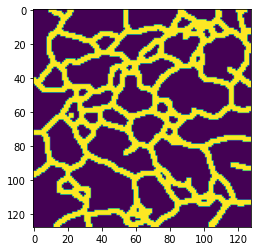

In [68]:
import matplotlib.pyplot as plt
# plt.imshow(timg_mp[0][0])

# timg_dilate = F.max_pool2d(timg_mp, (3,3), (1,1), (1,1))
plt.imshow(timg_dilate[0][0])

In [56]:
img1 = soft_open(timg)
skel = F.relu(timg-img1)

In [57]:
skel.shape

torch.Size([1, 1, 128, 128])

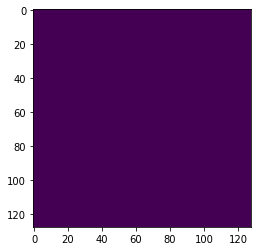

In [58]:
import matplotlib.pyplot as plt
plt.imshow(skel[0][0])